# KKBox Churn Prediction Kaggle Baseline

This baseline does the following:
- Combine train and test users
- Add member, transaction, and user-log aggregate features
- Generate strict historical labels with the reusable Churn Labeller
- Run expanding rolling validation to choose `BEST_ITER`
- Train an XGBoost binary classifier, and write `submission_baseline.csv`.


In [3]:
# Run this cell once if xgboost is missing from the active kernel.
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


## Imports and Configuration

In [4]:
from pathlib import Path
import gc
import sys
import warnings

import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
from IPython.display import display


def bootstrap_project_root(start=None):
    start_path = Path.cwd() if start is None else Path(start)
    for path in (start_path.resolve(), *start_path.resolve().parents):
        if (path / "src" / "data" / "churn_labeller.py").exists():
            return path

    fallback = Path(r"F:/KKBox's Churn Prediction Challenge")
    if (fallback / "src" / "data" / "churn_labeller.py").exists():
        return fallback

    raise FileNotFoundError("Could not find project root containing src/data/churn_labeller.py")


PROJECT_ROOT = bootstrap_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.baseline_features import (
    build_model_frame,
    build_transaction_aggregates_by_window,
    build_user_log_aggregates_by_window,
    load_member_features,
)
from src.utils.paths import find_project_root
from src.inference.baseline_submission import (
    load_train_and_submission_users,
    make_submission,
)
from src.models.baseline_xgb import (
    default_xgb_params,
    feature_importance_frame,
    make_dmatrix,
    plot_feature_importance,
    train_final_model,
)
from src.validation.rolling import (
    generate_rolling_labels,
    make_month_label_window,
    run_rolling_validation,
)

PROJECT_ROOT = find_project_root(PROJECT_ROOT)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)

RANDOM_STATE = 12345
BEST_ITER = 1512
CUTOFF_DATE_INT = 20170331
TRANSACTIONS_CHUNKSIZE = 2_000_000
USER_LOGS_CHUNKSIZE = 2_000_000
USE_KAGGLE_LEAK_FEATURES = True
TRANSACTION_FILES = ["transactions.csv", "transactions_v2.csv"]
USER_LOG_FILES = ["user_logs.csv", "user_logs_v2.csv"]

RUN_ROLLING_VALIDATION = True
ROLLING_USE_KAGGLE_LEAK_FEATURES = False
ROLLING_NUM_BOOST_ROUND = 1000
ROLLING_EARLY_STOPPING_ROUNDS = 50

XGB_PARAMS = default_xgb_params(random_state=RANDOM_STATE)

ROLLING_LABEL_WINDOWS = [
    make_month_label_window(2016, 11),
    make_month_label_window(2016, 12),
    make_month_label_window(2017, 1),
    make_month_label_window(2017, 2),
]

DATA_DIR = PROJECT_ROOT / "data" / "raw"
SAMPLE_SUBMISSION_PATH = PROJECT_ROOT / "outputs" / "submissions" / "sample_submission_v2.csv"
OUTPUT_PATH = PROJECT_ROOT / "outputs" / "submissions" / "baseline" / "submission_baseline.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"SAMPLE_SUBMISSION_PATH: {SAMPLE_SUBMISSION_PATH}")
print(f"OUTPUT_PATH: {OUTPUT_PATH}")
print(f"USE_KAGGLE_LEAK_FEATURES: {USE_KAGGLE_LEAK_FEATURES}")
print(f"RUN_ROLLING_VALIDATION: {RUN_ROLLING_VALIDATION}")
print(f"ROLLING_USE_KAGGLE_LEAK_FEATURES: {ROLLING_USE_KAGGLE_LEAK_FEATURES}")
print(f"TRANSACTION_FILES: {TRANSACTION_FILES}")
print(f"USER_LOG_FILES: {USER_LOG_FILES}")
display(pd.DataFrame(ROLLING_LABEL_WINDOWS))


PROJECT_ROOT: F:\KKBox's Churn Prediction Challenge
DATA_DIR: F:\KKBox's Churn Prediction Challenge\data\raw
SAMPLE_SUBMISSION_PATH: F:\KKBox's Churn Prediction Challenge\outputs\submissions\sample_submission_v2.csv
OUTPUT_PATH: F:\KKBox's Churn Prediction Challenge\outputs\submissions\baseline\submission_baseline.csv
USE_KAGGLE_LEAK_FEATURES: True
RUN_ROLLING_VALIDATION: True
ROLLING_USE_KAGGLE_LEAK_FEATURES: False
TRANSACTION_FILES: ['transactions.csv', 'transactions_v2.csv']
USER_LOG_FILES: ['user_logs.csv', 'user_logs_v2.csv']


,window,history_cutoff,target_expire_start,target_expire_end
0,2016_11,20161031,20161101,20161130
1,2016_12,20161130,20161201,20161231
2,2017_01,20161231,20170101,20170131
3,2017_02,20170131,20170201,20170228


## Load Train and Submission Users

- 测试数据的 `is_churn` 是 `NaN`
- 可选加入 Kaggle 泄露型重复用户特征 `is_duplicate`，由 `USE_KAGGLE_LEAK_FEATURES` 控制

In [5]:
train, sample_submission, final_base_data = load_train_and_submission_users(
    data_dir=DATA_DIR,
    sample_submission_path=SAMPLE_SUBMISSION_PATH,
    train_file="train_v2.csv",
)
data = final_base_data.copy()

print(f"train rows: {len(train):,}")
print(f"test rows: {len(sample_submission):,}")
print(f"combined rows: {len(final_base_data):,}")
display(final_base_data.head())


train rows: 970,960
test rows: 907,471
combined rows: 1,878,431


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1.0
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1.0
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1.0
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1.0
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1.0


## Rolling Churn Labels

Generate strict historical label windows with the reusable Churn Labeller. The March 2017 expiration window is intentionally excluded because strict labels would require April renewal observations, which are not available in the public transaction files.


In [6]:
if RUN_ROLLING_VALIDATION:
    rolling_labels_by_window, rolling_label_summary = generate_rolling_labels(
        data_dir=DATA_DIR,
        label_windows=ROLLING_LABEL_WINDOWS,
        transaction_files=TRANSACTION_FILES,
        official_train_path=DATA_DIR / "train.csv",
    )
    display(rolling_label_summary)
else:
    rolling_labels_by_window = {}
    rolling_label_summary = pd.DataFrame()
    print("RUN_ROLLING_VALIDATION=False: skipped rolling label generation.")


transaction rows available for labelling: 22,975,295
2016_11: labels=890,486, churn_rate=0.09088
2016_12: labels=880,724, churn_rate=0.08108
2017_01: labels=867,529, churn_rate=0.04510
2017_02: labels=879,537, churn_rate=0.03954
2017_02 official train.csv sanity: official_rows=992,931, labeller_rows=879,537, intersection=879,478, match_rate=0.983636, official_churn_rate=0.06392, labeller_churn_rate=0.03954


,window,history_cutoff,target_expire_start,target_expire_end,rows,churn_rate
0,2016_11,20161031,20161101,20161130,890486,0.090881
1,2016_12,20161130,20161201,20161231,880724,0.081081
2,2017_01,20161231,20170101,20170131,867529,0.045101
3,2017_02,20170131,20170201,20170228,879537,0.039545


## Member Feature Helpers


In [7]:
member_features = load_member_features(DATA_DIR)

print(f"member feature rows: {len(member_features):,}")
display(member_features.head())
_gc_members = gc.collect()


member feature rows: 6,769,473


,msno,city,bd,gender,registered_via,reg_fulldate,reg_year,reg_month,reg_mday,reg_wday
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1.0,0.0,0,11.0,20110912.0,2011.0,9.0,11.0,1.0
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1.0,0.0,0,7.0,20110914.0,2011.0,9.0,14.0,4.0
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1.0,0.0,0,11.0,20110916.0,2011.0,9.0,15.0,5.0
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1.0,0.0,0,11.0,20110916.0,2011.0,9.0,15.0,5.0
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6.0,32.0,1,9.0,20110916.0,2011.0,9.0,15.0,5.0


## Transaction Aggregates by Window

Read target-user transaction rows from `transactions.csv` and `transactions_v2.csv`. For rolling validation, every window uses only rows available by that window's `history_cutoff`; the final submission frame uses the v2 cutoff date `2017-03-31`.


In [8]:
# Transaction aggregate builders are imported from src.features.baseline_features.


In [9]:
target_msnos_by_window = {
    window_config["window"]: set(
        rolling_labels_by_window[window_config["window"]]["msno"].dropna().astype(str)
    )
    for window_config in ROLLING_LABEL_WINDOWS
    if window_config["window"] in rolling_labels_by_window
}
cutoff_by_window = {
    window_config["window"]: int(window_config["history_cutoff"])
    for window_config in ROLLING_LABEL_WINDOWS
    if window_config["window"] in rolling_labels_by_window
}

# Final submission users are the union of train_v2 and sample_submission_v2 IDs.
target_msnos_by_window["submission"] = set(final_base_data["msno"].dropna().astype(str).unique())
cutoff_by_window["submission"] = CUTOFF_DATE_INT

print("feature aggregation windows:")
display(
    pd.DataFrame(
        [
            {
                "window": key,
                "cutoff": cutoff_by_window[key],
                "target_users": len(target_msnos_by_window[key]),
            }
            for key in target_msnos_by_window
        ]
    )
)

transaction_aggs_by_window = build_transaction_aggregates_by_window(
    data_dir=DATA_DIR,
    target_msnos_by_window=target_msnos_by_window,
    cutoff_by_window=cutoff_by_window,
    transaction_files=TRANSACTION_FILES,
    chunksize=TRANSACTIONS_CHUNKSIZE,
)
transactions_agg = transaction_aggs_by_window["submission"]
rolling_transaction_aggs = {
    key: transaction_aggs_by_window[key]
    for key in rolling_labels_by_window
}

display(transactions_agg.head())
_gc_transaction = gc.collect()


feature aggregation windows:


,window,cutoff,target_users
0,2016_11,20161031,890486
1,2016_12,20161130,880724
2,2017_01,20161231,867529
3,2017_02,20170131,879537
4,submission,20170331,1076941


transactions.csv chunk 1: file_seen=2,000,000, kept 2016_11=1,050,128, 2016_12=1,107,983, 2017_01=1,150,777, 2017_02=1,218,272, submission=1,475,004
transactions.csv chunk 2: file_seen=4,000,000, kept 2016_11=1,049,603, 2016_12=1,106,902, 2017_01=1,150,035, 2017_02=1,217,678, submission=1,475,477
transactions.csv chunk 3: file_seen=6,000,000, kept 2016_11=1,049,553, 2016_12=1,107,330, 2017_01=1,150,694, 2017_02=1,217,736, submission=1,475,353
transactions.csv chunk 4: file_seen=8,000,000, kept 2016_11=1,049,166, 2016_12=1,107,437, 2017_01=1,149,524, 2017_02=1,217,122, submission=1,474,901
transactions.csv chunk 5: file_seen=10,000,000, kept 2016_11=1,049,845, 2016_12=1,107,378, 2017_01=1,150,099, 2017_02=1,217,469, submission=1,475,582
transactions.csv chunk 6: file_seen=12,000,000, kept 2016_11=1,049,398, 2016_12=1,107,130, 2017_01=1,149,796, 2017_02=1,216,877, submission=1,474,626
transactions.csv chunk 7: file_seen=14,000,000, kept 2016_11=1,049,491, 2016_12=1,107,903, 2017_01=1,150

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,payment_price_diff,n_transactions
0,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,41.0,30.000000,99.000000,99.0,1.0,0.0,0.000000,5.0
1,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,39.0,28.714285,141.904755,149.0,1.0,0.0,-7.095238,21.0
2,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,41.0,28.888889,143.481476,149.0,1.0,0.0,-5.518518,27.0
3,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,41.0,30.000000,149.000000,149.0,1.0,0.0,0.000000,13.0
4,++/UDNo9DLrxT8QVGiDi1OnWfczAdEwThaVyD0fXO50=,39.0,28.714285,141.904755,149.0,1.0,0.0,-7.095238,21.0


In [10]:
transactions_agg.describe()

,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,payment_price_diff,n_transactions
count,1.076941e+06,1.076941e+06,1.076941e+06,1.076941e+06,1.076941e+06,1.076941e+06,1.076941e+06,1.076941e+06
mean,3.872859e+01,3.709032e+01,1.595171e+02,1.619376e+02,8.425657e-01,1.574903e-02,-2.420535e+00,1.590916e+01
std,3.744837e+00,4.310096e+01,1.841974e+02,1.843120e+02,3.451768e-01,4.107907e-02,1.382390e+01,9.052711e+00
min,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.788000e+03,1.000000e+00
25%,3.782353e+01,2.896552e+01,9.900000e+01,9.900000e+01,1.000000e+00,0.000000e+00,-4.448276e+00,8.000000e+00
50%,4.100000e+01,3.000000e+01,1.355862e+02,1.418571e+02,1.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01
75%,4.100000e+01,3.000000e+01,1.490000e+02,1.490000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.300000e+01
max,4.100000e+01,4.500000e+02,2.000000e+03,2.000000e+03,1.000000e+00,1.000000e+00,1.490000e+02,2.440000e+02


## User Log Aggregates by Window


In [11]:
user_log_aggs_by_window = build_user_log_aggregates_by_window(
    data_dir=DATA_DIR,
    target_msnos_by_window=target_msnos_by_window,
    cutoff_by_window=cutoff_by_window,
    user_log_files=USER_LOG_FILES,
    chunksize=USER_LOGS_CHUNKSIZE,
)
user_logs_agg = user_log_aggs_by_window["submission"]
rolling_user_log_aggs = {
    key: user_log_aggs_by_window[key]
    for key in rolling_labels_by_window
}

display(user_logs_agg.head())
_gc_user_logs = gc.collect()


user_logs.csv chunk 1: file_seen=2,000,000, kept 2016_11=857,923, 2016_12=903,391, 2017_01=945,765, 2017_02=987,816, submission=1,300,865
user_logs.csv chunk 2: file_seen=4,000,000, kept 2016_11=857,792, 2016_12=901,872, 2017_01=947,016, 2017_02=990,267, submission=1,300,227
user_logs.csv chunk 3: file_seen=6,000,000, kept 2016_11=859,699, 2016_12=904,753, 2017_01=947,193, 2017_02=993,945, submission=1,302,884
user_logs.csv chunk 4: file_seen=8,000,000, kept 2016_11=861,322, 2016_12=908,163, 2017_01=950,432, 2017_02=993,871, submission=1,304,721
user_logs.csv chunk 5: file_seen=10,000,000, kept 2016_11=861,728, 2016_12=904,511, 2017_01=949,021, 2017_02=993,050, submission=1,305,590
user_logs.csv chunk 6: file_seen=12,000,000, kept 2016_11=858,620, 2016_12=903,781, 2017_01=946,755, 2017_02=991,508, submission=1,302,135
user_logs.csv chunk 7: file_seen=14,000,000, kept 2016_11=858,080, 2016_12=905,935, 2017_01=947,629, 2017_02=991,911, submission=1,302,324
user_logs.csv chunk 8: file_see

,msno,ul_active_days,ul_num_25_sum,ul_num_25_mean,ul_num_50_sum,ul_num_50_mean,ul_num_75_sum,ul_num_75_mean,ul_num_985_sum,ul_num_985_mean,ul_num_100_sum,ul_num_100_mean,ul_num_unq_sum,ul_num_unq_mean,ul_total_secs_sum,ul_total_secs_mean
0,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,134.0,763.0,5.694030,379.0,2.828358,359.0,2.679105,648.0,4.835821,2820.0,21.044777,3690.0,27.537313,912410.625,6809.034180
1,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,637.0,1439.0,2.259027,506.0,0.794349,435.0,0.682889,573.0,0.899529,16057.0,25.207222,15745.0,24.717426,4176973.750,6557.258789
2,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,624.0,6895.0,11.049680,2376.0,3.807692,1576.0,2.525641,1466.0,2.349359,24243.0,38.850960,25492.0,40.852566,6832941.500,10950.226562
3,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,321.0,1543.0,4.806854,473.0,1.473520,389.0,1.211838,506.0,1.576324,5571.0,17.355141,4094.0,12.753894,1602234.625,4991.385254
4,++/UDNo9DLrxT8QVGiDi1OnWfczAdEwThaVyD0fXO50=,466.0,1157.0,2.482833,558.0,1.197425,309.0,0.663090,416.0,0.892704,4933.0,10.585837,6858.0,14.716738,1435438.375,3080.339844


## Merge Features and Build Matrices

把前面做好的特征合并到主数据里，然后拆分训练集和测试集

In [12]:
# Build the final train/test feature frame.
data, features, feature_names = build_model_frame(
    final_base_data,
    transaction_agg=transactions_agg,
    user_log_agg=user_logs_agg,
    use_duplicate=USE_KAGGLE_LEAK_FEATURES,
    member_features=member_features,
)

if USE_KAGGLE_LEAK_FEATURES:
    print("USE_KAGGLE_LEAK_FEATURES=True: added is_duplicate feature")
else:
    print("USE_KAGGLE_LEAK_FEATURES=False: skipped is_duplicate feature")

train_mask = data["is_churn"].notna()
test_mask = data["is_churn"].isna()
y_train = data.loc[train_mask, "is_churn"].astype("float32").to_numpy()
test_ids = data.loc[test_mask, "msno"].copy()

if len(y_train) != len(train):
    raise AssertionError(f"Expected {len(train):,} training rows, got {len(y_train):,}.")
if len(test_ids) != len(sample_submission):
    raise AssertionError(
        f"Expected {len(sample_submission):,} test rows, got {len(test_ids):,}."
    )

train_sparse = sparse.csr_matrix(features.loc[train_mask].to_numpy(dtype=np.float32))
test_sparse = sparse.csr_matrix(features.loc[test_mask].to_numpy(dtype=np.float32))

if train_sparse.shape[1] != len(feature_names):
    raise AssertionError("Feature name count does not match train matrix columns.")
if test_sparse.shape[1] != len(feature_names):
    raise AssertionError("Feature name count does not match test matrix columns.")

print(f"feature count: {len(feature_names):,}")
print(f"train matrix: {train_sparse.shape}")
print(f"test matrix: {test_sparse.shape}")
display(features.head())


USE_KAGGLE_LEAK_FEATURES=True: added is_duplicate feature
feature count: 33
train matrix: (970960, 33)
test matrix: (907471, 33)


,is_duplicate,city,bd,gender,registered_via,reg_fulldate,reg_year,reg_month,reg_mday,reg_wday,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,payment_price_diff,n_transactions,ul_active_days,ul_num_25_sum,ul_num_25_mean,ul_num_50_sum,ul_num_50_mean,ul_num_75_sum,ul_num_75_mean,ul_num_985_sum,ul_num_985_mean,ul_num_100_sum,ul_num_100_mean,ul_num_unq_sum,ul_num_unq_mean,ul_total_secs_sum,ul_total_secs_mean
0,0.0,5.0,28.0,2.0,3.0,20131224.0,2013.0,12.0,23.0,2.0,32.166668,10.000000,49.666668,149.000000,0.833333,0.166667,-99.333336,6.0,64.0,553.0,8.640625,107.0,1.671875,57.0,0.890625,92.0,1.437500,2031.0,31.734375,778.0,12.156250,4.808940e+05,7513.968262
1,1.0,13.0,20.0,2.0,3.0,20131224.0,2013.0,12.0,23.0,2.0,36.833332,26.166666,134.500000,134.500000,0.000000,0.000000,0.000000,6.0,80.0,147.0,1.837500,45.0,0.562500,23.0,0.287500,25.0,0.312500,808.0,10.100000,733.0,9.162500,2.170232e+05,2712.790527
2,0.0,13.0,18.0,2.0,3.0,20131228.0,2013.0,12.0,27.0,6.0,35.799999,34.500000,149.100006,149.100006,0.000000,0.000000,0.000000,20.0,342.0,10784.0,31.532164,781.0,2.283626,423.0,1.236842,421.0,1.230994,6686.0,19.549707,15298.0,44.730995,1.931848e+06,5648.679688
3,0.0,1.0,0.0,0.0,7.0,20140108.0,2014.0,1.0,9.0,5.0,40.793102,27.137932,133.586212,143.862076,0.965517,0.103448,-10.275862,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,13.0,35.0,1.0,7.0,20140124.0,2014.0,1.0,25.0,7.0,41.000000,27.187500,103.781250,117.125000,1.000000,0.093750,-13.343750,32.0,271.0,317.0,1.169742,194.0,0.715867,119.0,0.439114,75.0,0.276753,4053.0,14.955720,3907.0,14.416974,1.050059e+06,3874.755615


## Rolling Validation

Use expanding historical folds: train on earlier labelled windows and validate on the next window. Each window's labels and features are both cut at that window's `history_cutoff`.


In [13]:
if RUN_ROLLING_VALIDATION:
    rolling_results, BEST_ITER = run_rolling_validation(
        rolling_labels_by_window=rolling_labels_by_window,
        transaction_aggs_by_window=rolling_transaction_aggs,
        user_log_aggs_by_window=rolling_user_log_aggs,
        member_features=member_features,
        label_windows=ROLLING_LABEL_WINDOWS,
        xgb_params=XGB_PARAMS,
        num_boost_round=ROLLING_NUM_BOOST_ROUND,
        early_stopping_rounds=ROLLING_EARLY_STOPPING_ROUNDS,
        use_duplicate=ROLLING_USE_KAGGLE_LEAK_FEATURES,
    )
    display(rolling_results)
    print(f"BEST_ITER set from rolling validation median: {BEST_ITER}")
else:
    rolling_results = pd.DataFrame()
    print(f"RUN_ROLLING_VALIDATION=False: using configured BEST_ITER={BEST_ITER}")

assert BEST_ITER >= 1


2016_11: matrix=(890486, 32), churn_rate=0.09088
2016_12: matrix=(880724, 32), churn_rate=0.08108
2017_01: matrix=(867529, 32), churn_rate=0.04510
2017_02: matrix=(879537, 32), churn_rate=0.03954
rolling fold 1: train_windows=['2016_11'], valid_window=2016_12, train_rows=890,486, valid_rows=880,724
[0]	train-logloss:0.29276	valid-logloss:0.27544
[50]	train-logloss:0.15107	valid-logloss:0.19906
[100]	train-logloss:0.12457	valid-logloss:0.19485
[137]	train-logloss:0.11808	valid-logloss:0.19956
rolling fold 2: train_windows=['2016_11', '2016_12'], valid_window=2017_01, train_rows=1,771,210, valid_rows=867,529
[0]	train-logloss:0.28355	valid-logloss:0.19393
[50]	train-logloss:0.17033	valid-logloss:0.14609
[100]	train-logloss:0.15011	valid-logloss:0.13465
[150]	train-logloss:0.14403	valid-logloss:0.13173
[200]	train-logloss:0.14177	valid-logloss:0.13070
[250]	train-logloss:0.14078	valid-logloss:0.13019
[300]	train-logloss:0.13994	valid-logloss:0.12987
[350]	train-logloss:0.13930	valid-loglo

,valid_window,train_windows,train_rows,valid_rows,valid_churn_rate,best_iteration,valid_logloss
0,2016_12,2016_11,890486,880724,0.081081,88,0.194140
1,2017_01,"2016_11,2016_12",1771210,867529,0.045101,656,0.128939
2,2017_02,"2016_11,2016_12,2017_01",2638739,879537,0.039545,989,0.122202


BEST_ITER set from rolling validation median: 656


## Train XGBoost

In [14]:
# Convert the final train/test matrices into XGBoost's native DMatrix format.
dtrain = make_dmatrix(
    data=train_sparse,
    label=y_train,
    feature_names=feature_names,
)
dtest = make_dmatrix(
    data=test_sparse,
    feature_names=feature_names,
)

# Train the final model with the rolling-validation-selected number of rounds.
xgb_model = train_final_model(
    dtrain=dtrain,
    xgb_params=XGB_PARAMS,
    num_boost_round=BEST_ITER,
    verbose_eval=100,
)


[0]	train-logloss:0.29048
[100]	train-logloss:0.11450
[200]	train-logloss:0.10037
[300]	train-logloss:0.09701
[400]	train-logloss:0.09534
[500]	train-logloss:0.09430
[600]	train-logloss:0.09333
[655]	train-logloss:0.09281


## Feature Importance

确认：

- 哪些特征被模型使用了
- 哪些特征对预测贡献最大
- 哪些特征可能不太重要

,feature,gain
0,is_duplicate,6372.091309
1,is_auto_renew,516.983826
2,payment_price_diff,356.815033
3,is_cancel,193.368134
4,payment_plan_days,171.390732
5,payment_method_id,145.628326
6,plan_list_price,117.105095
7,city,85.349297
8,n_transactions,68.101913
9,ul_active_days,67.649750


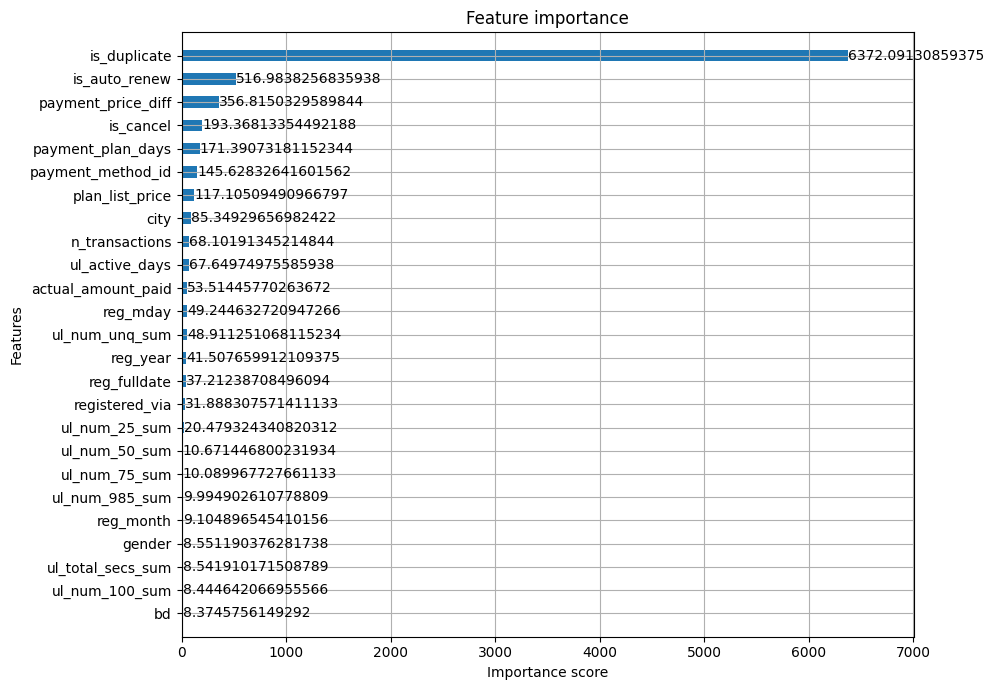

In [15]:
importance_df = feature_importance_frame(xgb_model, importance_type="gain")

display(importance_df)

ax = plot_feature_importance(
    xgb_model,
    max_num_features=min(25, len(feature_names)),
    importance_type="gain",
    height=0.5,
)
ax.figure.set_size_inches(10, 7)
plt.tight_layout()
plt.show()


## Predict and Write Submission

The final CSV is written to `OUTPUT_PATH`, with the same `msno` order as `sample_submission_v2.csv`.


In [16]:
submission = make_submission(
    sample_submission=sample_submission,
    test_ids=test_ids,
    predictions=xgb_model.predict(dtest),
    output_path=OUTPUT_PATH,
)

print(f"wrote {len(submission):,} rows to {OUTPUT_PATH}")
display(submission.head())


wrote 907,471 rows to F:\KKBox's Churn Prediction Challenge\outputs\submissions\baseline\submission_baseline.csv


,msno,is_churn
0,4n+fXlyJvfQnTeKXTWT507Ll4JVYGrOC8LHCfwBmPE4=,0.000135
1,aNmbC1GvFUxQyQUidCVmfbQ0YeCuwkPzEdQ0RwWyeZM=,0.000460
2,rFC9eSG/tMuzpre6cwcMLZHEYM89xY02qcz7HL4//jc=,0.001640
3,WZ59dLyrQcE7ft06MZ5dj40BnlYQY7PHgg/54+HaCSE=,0.000106
4,aky/Iv8hMp1/V/yQHLtaVuEmmAxkB5GuasQZePJ7NU4=,0.001666
